In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
R = np.array([
    [3, 0],
    [4, 0]
])

m = R.shape[1]

r_bar = R @ np.ones(m) / m
X = R - r_bar[:, None]

print("Mean vector:")
print(r_bar)

print("\nCentered matrix:")
print(X)

print("\nRow sums:")
print(X.sum(axis=1))

Mean vector:
[1.5 2. ]

Centered matrix:
[[ 1.5 -1.5]
 [ 2.  -2. ]]

Row sums:
[0. 0.]


In [4]:
#import from lecture 3
data = pd.read_csv("market_data_2007_2025.csv")
data["Date"] = pd.to_datetime(data["Date"])
data = data.set_index("Date")

prices = data[[
    "SPY_Adj_Close",
    "QQQ_Adj_Close",
    "TLT_Adj_Close",
    "HYG_Adj_Close",
    "VIX_Close"
]]
prices.columns = ["SPY", "QQQ", "TLT", "HYG", "VIX"]

log_changes = np.log(prices).diff().dropna()

R = log_changes.T.to_numpy()
dates = log_changes.index

In [5]:
print("Shape:", R.shape)
print("First date:", dates[0])
print("Last date:", dates[-1])
print("Row order: SPY, QQQ, TLT, HYG, VIX")

Shape: (5, 4712)
First date: 2007-04-12 00:00:00
Last date: 2025-12-31 00:00:00
Row order: SPY, QQQ, TLT, HYG, VIX


In [6]:
m = R.shape[1]

r_bar = R @ np.ones(m) / m
X = R - r_bar[:, None]

In [7]:
s = np.sqrt(np.mean(X**2, axis=1))
print(s)

[0.01250852 0.01408005 0.00961727 0.00692031 0.07714686]


In [8]:
Z = X / s[:, None]

In [9]:
row_means = np.mean(Z, axis=1)
row_variances = np.var(Z, axis=1)

print("Row means:", row_means)
print("Row variances:", row_variances)

Row means: [ 1.50794299e-18  1.96032588e-17 -1.20635439e-17 -9.42464367e-18
 -1.07440938e-17]
Row variances: [1. 1. 1. 1. 1.]


In [10]:
U, sigma, Vt = np.linalg.svd(Z, full_matrices=False)
Y = U.T @ Z

C_Z = Z @ Z.T / m
eigenvalues, eigenvectors = np.linalg.eigh(C_Z)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Singular values:", sigma)
print("Eigenvalues:", eigenvalues)
print("sigma^2 / m:", sigma**2 / m)

Singular values: [122.77186576  65.43572424  49.61861925  37.84859449  17.62701027]
Eigenvalues: [3.19883935 0.90870841 0.52249732 0.30401445 0.06594047]
sigma^2 / m: [3.19883935 0.90870841 0.52249732 0.30401445 0.06594047]


In [11]:
corr_spy_pc1 = np.corrcoef(Y[0, :], Z[0, :])[0, 1]
print(corr_spy_pc1)

-0.9599783546673651


In [12]:
print("PC1-SPY correlation:", np.corrcoef(Y[0, :], Z[0, :])[0, 1])
print("Loadings:")
print(U)

PC1-SPY correlation: -0.9599783546673651
Loadings:
[[-0.53674156  0.05486835  0.03771315  0.34484587 -0.76717469]
 [-0.51837313  0.08458152  0.17539886  0.55047195  0.62478088]
 [ 0.21935476  0.95274663  0.19625333  0.05531466 -0.05081609]
 [-0.42271387  0.2846345  -0.78179637 -0.33628201  0.12651103]
 [ 0.46518198 -0.03305297 -0.56399648  0.67964451 -0.05004537]]


In [13]:
U[:, 0] *= -1
Vt[0, :] *= -1
Y[0, :] *= -1

In [14]:
print("PC1-SPY correlation:", np.corrcoef(Y[0, :], Z[0, :])[0, 1])
print("Loadings:")
print(U)

PC1-SPY correlation: 0.9599783546673651
Loadings:
[[ 0.53674156  0.05486835  0.03771315  0.34484587 -0.76717469]
 [ 0.51837313  0.08458152  0.17539886  0.55047195  0.62478088]
 [-0.21935476  0.95274663  0.19625333  0.05531466 -0.05081609]
 [ 0.42271387  0.2846345  -0.78179637 -0.33628201  0.12651103]
 [-0.46518198 -0.03305297 -0.56399648  0.67964451 -0.05004537]]


In [15]:
U[:, 2] *= -1
Vt[2, :] *= -1
Y[2, :] *= -1

U[:, 4] *= -1
Vt[4, :] *= -1
Y[4, :] *= -1
print(U)

[[ 0.53674156  0.05486835 -0.03771315  0.34484587  0.76717469]
 [ 0.51837313  0.08458152 -0.17539886  0.55047195 -0.62478088]
 [-0.21935476  0.95274663 -0.19625333  0.05531466  0.05081609]
 [ 0.42271387  0.2846345   0.78179637 -0.33628201 -0.12651103]
 [-0.46518198 -0.03305297  0.56399648  0.67964451  0.05004537]]


In [16]:
for k in range(5):
    if np.dot(eigenvectors[:, k], U[:, k]) < 0:
        eigenvectors[:, k] *= -1

In [17]:
print(np.max(np.abs(eigenvectors - U)))

8.881784197001252e-16


In [18]:
print(np.max(np.abs(Z.T @ U - (sigma[:, None] * Vt).T)))

8.415490526658687e-14


In [19]:
d_eigenvalues = np.max(np.abs(eigenvalues - sigma**2 / m))
d_loadings = np.max(np.abs(eigenvectors - U))
Y_cov = eigenvectors.T @ Z
d_scores = np.max(np.abs(Y_cov - Y))
print(d_eigenvalues)
print(d_loadings)
print(d_scores)

2.6645352591003757e-15
8.881784197001252e-16
1.2434497875801753e-14


In [20]:
#variance tests
total_var_assets = np.sum(np.var(Z, axis=1))
total_var_frobenius = np.sum(Z**2) / m
total_var_pca = np.sum(eigenvalues)
print(total_var_assets)
print(total_var_frobenius)
print(total_var_pca)

5.0
5.0
4.999999999999998


In [23]:
#EVR
EVR = eigenvalues / total_var_pca
CEV = np.cumsum(EVR)
print(EVR)
print(CEV)

[0.63976787 0.18174168 0.10449946 0.06080289 0.01318809]
[0.63976787 0.82150955 0.92600902 0.98681191 1.        ]


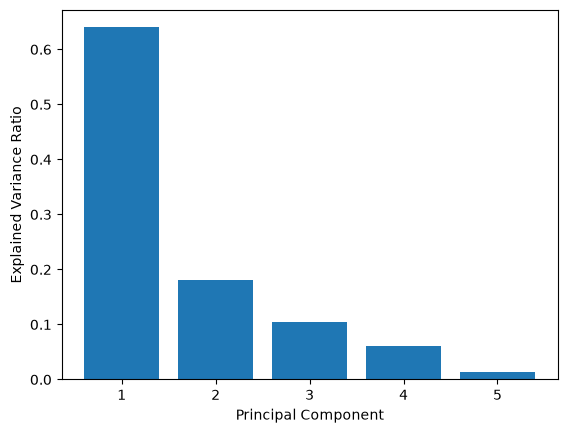

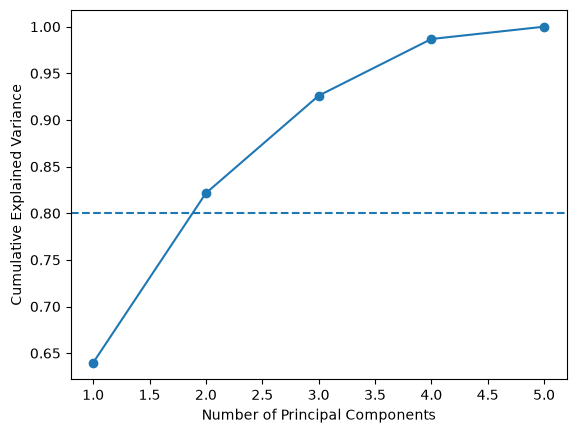

In [24]:
k = np.arange(1, 6)

plt.figure()
plt.bar(k, EVR)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.show()

plt.figure()
plt.plot(k, CEV, marker="o")
plt.axhline(0.8, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

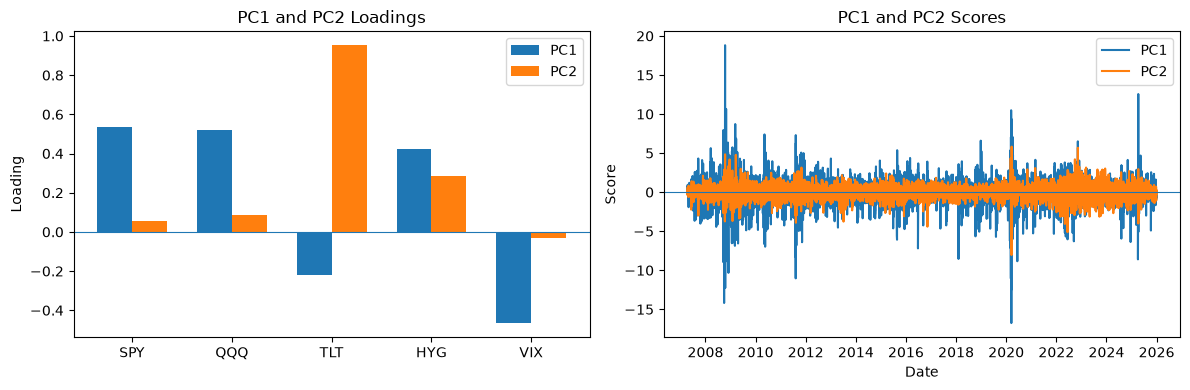

In [25]:
assets = ["SPY", "QQQ", "TLT", "HYG", "VIX"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# PC1 and PC2 loadings
x = np.arange(len(assets))
width = 0.35
ax[0].bar(x - width/2, U[:, 0], width, label="PC1")
ax[0].bar(x + width/2, U[:, 1], width, label="PC2")
ax[0].axhline(0, linewidth=0.8)
ax[0].set_xticks(x)
ax[0].set_xticklabels(assets)
ax[0].set_ylabel("Loading")
ax[0].set_title("PC1 and PC2 Loadings")
ax[0].legend()

# PC1 and PC2 scores
ax[1].plot(dates, Y[0, :], label="PC1")
ax[1].plot(dates, Y[1, :], label="PC2")
ax[1].axhline(0, linewidth=0.8)
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Score")
ax[1].set_title("PC1 and PC2 Scores")
ax[1].legend()

plt.tight_layout()
plt.show()

In [26]:
i1 = np.argmax(np.abs(Y[0, :]))

print("Date:", dates[i1])
print("PC1 score:", Y[0, i1])

Date: 2008-10-13 00:00:00
PC1 score: 18.81025126296288


In [27]:
i2 = np.argmax(np.abs(Y[1, :]))

print("Date:", dates[i2])
print("PC2 score:", Y[1, i2])

Date: 2020-03-18 00:00:00
PC2 score: -8.05069532238882


In [28]:
print("2008-10-13:")
print(Z[:, i1])

print("\n2020-03-18:")
print(Z[:, i2])

2008-10-13:
[10.80650921  8.11134902 -1.35411374 16.69481157 -3.11938911]

2020-03-18:
[-4.18624058 -2.23570676 -6.05033217 -6.55030419  0.09159941]


The largest absolute PC1 score occurs on 13 October 2008, with a positive score of 18.81. The standardized return vector on this date has positive values for SPY, QQQ and HYG and negative values for TLT and VIX, which aligns closely with the signs of the PC1 loadings and therefore produces a large positive score. The largest absolute PC2 score occurs on 18 March 2020, with a negative score of −8.05. On this date TLT and HYG, which have positive PC2 loadings, have strongly negative standardized returns, so the return vector points largely in the opposite direction to PC2, resulting in a negative score.

PC1 squared-energy fraction:
Raw R:          0.9555
Centered X:     0.9556
Standardized Z: 0.6398

Smallest K with at least 80% cumulative variance:
Raw R:          1
Centered X:     1
Standardized Z: 2


,R PC1,R PC2,R PC3,R PC4,R PC5,X PC1,X PC2,X PC3,X PC4,X PC5,Z PC1,Z PC2,Z PC3,Z PC4,Z PC5
SPY,0.120689,0.600749,0.078480,0.107409,0.778999,0.120682,0.600756,0.080067,0.107130,0.778872,0.536742,0.054868,0.037713,0.344846,0.767175
QQQ,0.131705,0.699005,0.180914,-0.440546,-0.516947,0.131695,0.698359,0.182349,-0.440697,-0.517190,0.518373,0.084582,0.175399,0.550472,-0.624781
TLT,-0.031820,-0.214210,0.972269,-0.041535,0.077901,-0.031822,-0.216492,0.971766,-0.041743,0.077760,-0.219355,0.952747,0.196253,0.055315,0.050816
HYG,0.043416,0.264500,0.125459,0.890298,-0.346099,0.043412,0.264355,0.126247,0.890247,-0.346055,0.422714,0.284635,-0.781796,-0.336282,-0.126511
VIX,-0.982441,0.186134,0.007948,-0.005175,0.008577,-0.982443,0.186103,0.008381,-0.005225,0.008537,-0.465182,-0.033053,-0.563996,0.679645,0.050045


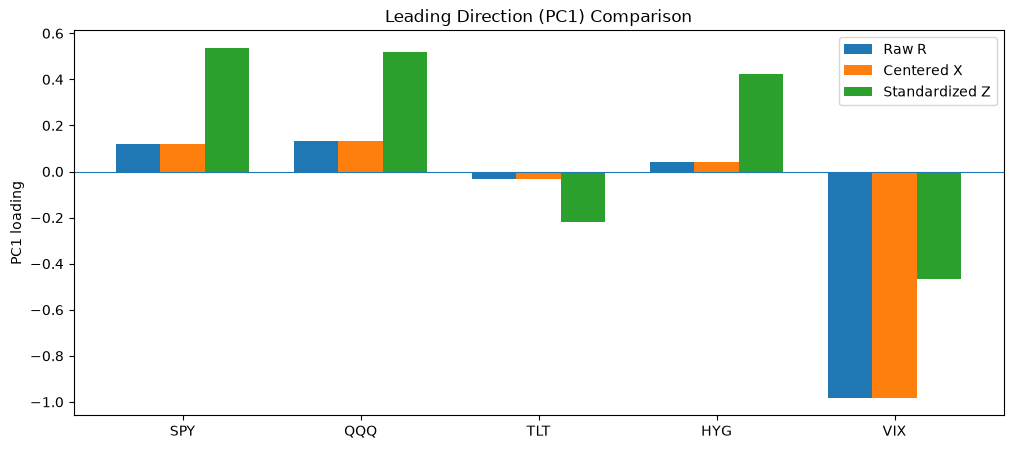

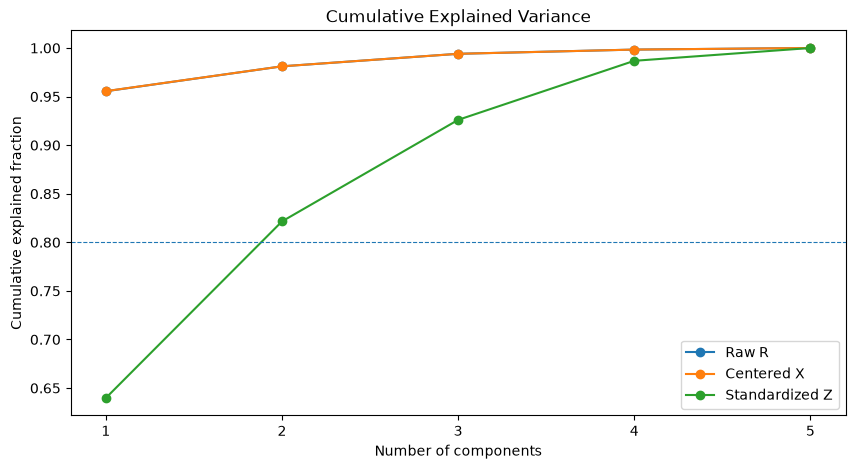

In [29]:
assets = ["SPY", "QQQ", "TLT", "HYG", "VIX"]

def run_svd(A):
    U, sigma, Vt = np.linalg.svd(A, full_matrices=False)
    scores = U.T @ A
    for k in range(U.shape[1]):
        if np.corrcoef(scores[k, :], A[0, :])[0, 1] < 0:
            U[:, k] *= -1
            Vt[k, :] *= -1
            scores[k, :] *= -1
    energy = sigma**2 / np.sum(sigma**2)
    CEV = np.cumsum(energy)
    K80 = np.argmax(CEV >= 0.80) + 1
    return U, sigma, Vt, scores, energy, CEV, K80

U_R, sigma_R, Vt_R, Y_R, energy_R, CEV_R, K_R = run_svd(R)
U_X, sigma_X, Vt_X, Y_X, energy_X, CEV_X, K_X = run_svd(X)
U_Z, sigma_Z, Vt_Z, Y_Z, energy_Z, CEV_Z, K_Z = run_svd(Z)

print("PC1 squared-energy fraction:")
print(f"Raw R:          {energy_R[0]:.4f}")
print(f"Centered X:     {energy_X[0]:.4f}")
print(f"Standardized Z: {energy_Z[0]:.4f}")

print("\nSmallest K with at least 80% cumulative variance:")
print(f"Raw R:          {K_R}")
print(f"Centered X:     {K_X}")
print(f"Standardized Z: {K_Z}")

loading_table = pd.DataFrame({
    "R PC1": U_R[:, 0],
    "R PC2": U_R[:, 1],
    "R PC3": U_R[:, 2],
    "R PC4": U_R[:, 3],
    "R PC5": U_R[:, 4],
    "X PC1": U_X[:, 0],
    "X PC2": U_X[:, 1],
    "X PC3": U_X[:, 2],
    "X PC4": U_X[:, 3],
    "X PC5": U_X[:, 4],
    "Z PC1": U_Z[:, 0],
    "Z PC2": U_Z[:, 1],
    "Z PC3": U_Z[:, 2],
    "Z PC4": U_Z[:, 3],
    "Z PC5": U_Z[:, 4]
}, index=assets)

display(loading_table)

plt.figure(figsize=(12, 5))
x = np.arange(len(assets))
width = 0.25
for i, (U_mat, label) in enumerate([(U_R, "Raw R"), (U_X, "Centered X"), (U_Z, "Standardized Z")]):
    plt.bar(x + (i - 1) * width, U_mat[:, 0], width, label=label)
plt.axhline(0, linewidth=0.8)
plt.xticks(x, assets)
plt.ylabel("PC1 loading")
plt.title("Leading Direction (PC1) Comparison")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
k = np.arange(1, 6)
plt.plot(k, CEV_R, marker="o", label="Raw R")
plt.plot(k, CEV_X, marker="o", label="Centered X")
plt.plot(k, CEV_Z, marker="o", label="Standardized Z")
plt.axhline(0.80, linestyle="--", linewidth=0.8)
plt.xticks(k)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained fraction")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.show()